In [39]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-codex")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import h5py
import pickle
os.makedirs("figures/Supplement_figures/MS2_validation", exist_ok=True)
%config InlineBackend.figure_format = 'retina'

In [40]:
df = pd.read_csv("Data/aggregated_MS2_test_results.csv")
print(df.columns)

Index(['AUC', 'Best_TPR', 'Best_FPR', 'mean_event_deviation',
       'std_event_deviation', 'avg_event_number', 'pred_loading_rate_on',
       'pred_loading_rate_off', 'pred_loading_rate_on_std',
       'pred_loading_rate_off_std', 'pred_kon', 'pred_koff', 'pred_kon_std',
       'pred_koff_std', 'true_kon', 'true_koff', 'loading_rate', 'snr', 'dt',
       'ntraj', 'state_deviation_mean', 'state_deviation_std'],
      dtype='object')


In [41]:

colors_pt = {
        "blue": "#0077BB",
        "magenta": "#EE3377",
        "teal": "#009988",
        "orange": "#EE7733",
        "cyan": "#33BBEE",
        "red": "#CC3311",
        "grey": "#BBBBBB",
    }

from matplotlib.colors import LinearSegmentedColormap


pt_heatmap_cmap = LinearSegmentedColormap.from_list(
    "PT_Inferno",
    [
        (0.00, "#000000"),
        (0.35, colors_pt["blue"]),
        (0.65, colors_pt["magenta"]),
        (0.85, colors_pt["orange"]),
        (1.00, "#FFDDAA"),
    ],
)


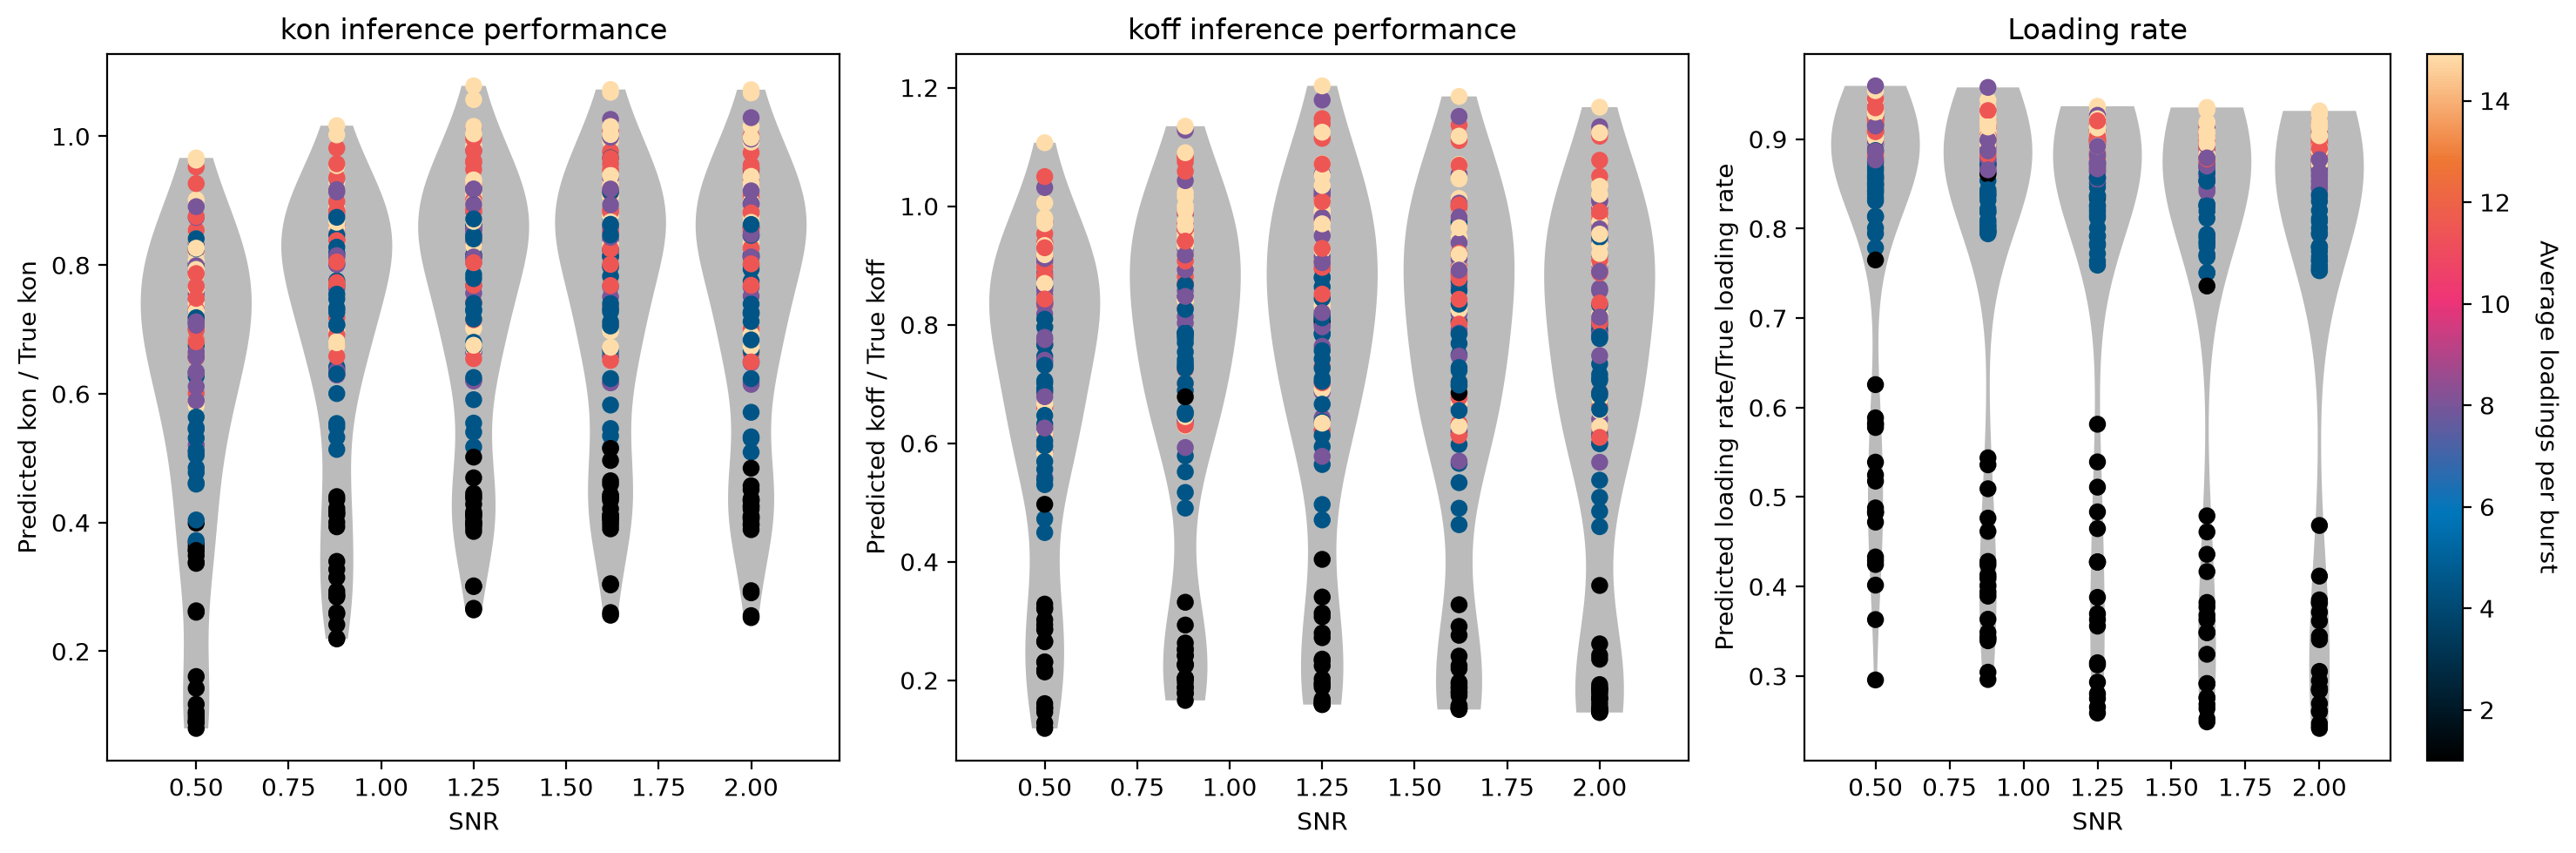

In [47]:

scatter_h5_path = "Data/aggregated_MS2_test_scatter_values.h5"
scatter_sample_n = 500_000
scatter_rng = np.random.default_rng(42)

def sample_h5_pair(handle, x_name, y_name, sample_n, rng):
    n = handle[x_name].shape[0]
    if n <= sample_n:
        return handle[x_name][:], handle[y_name][:]
    step = max(n // sample_n, 1)
    offset = int(rng.integers(0, step))
    stop = min(n, offset + step * sample_n)
    return handle[x_name][offset:stop:step], handle[y_name][offset:stop:step]

with h5py.File(scatter_h5_path, "r") as h5:
    true_state, pred_state = sample_h5_pair(
        h5, "true_promoter_state", "pred_promoter_state", scatter_sample_n, scatter_rng
    )
    true_ms2, pred_ms2 = sample_h5_pair(
        h5, "true_ms2", "pred_ms2", scatter_sample_n, scatter_rng
    )
    n_state_total = h5["true_promoter_state"].shape[0]
    n_ms2_total = h5["true_ms2"].shape[0]




fig,all_axes = plt.subplots(1,3,figsize=(15,5))
axes = all_axes.flatten()


for i,ax in enumerate(axes[:2]):
    val = ["kon","koff"][i]
    unique_vals = np.unique(df[f"true_{val}"])
    # add violin-plot on top
    #grab datasets for each snr values
    datasets = [df[df["snr"]==snr][f"pred_{val}"]/df[df["snr"]==snr][f"true_{val}"] for snr in df["snr"].unique()]
    ax.violinplot(datasets, positions=df["snr"].unique(),showextrema=False,widths=0.3,facecolor=colors_pt["grey"])
    
    ax.scatter(df["snr"],df[f"pred_{val}"]/df[f"true_{val}"],c=df["loading_rate"]/df["true_koff"],cmap=pt_heatmap_cmap)
    
    ax.set(xlabel="SNR", ylabel=f"Predicted {val} / True {val}", title=f"{val} inference performance")
    
# add loading rate 
axes[2].violinplot([df[df["snr"]==snr]["pred_loading_rate_on"]/df[df["snr"]==snr]["loading_rate"] for snr in df["snr"].unique()], positions=df["snr"].unique(),showextrema=False,widths=0.3,facecolor=colors_pt["grey"])
im = axes[2].scatter(df["snr"],df["pred_loading_rate_on"] / df["loading_rate"],c=df["loading_rate"]/df["true_koff"],cmap=pt_heatmap_cmap)
cbar = fig.colorbar(im, ax=axes[-1])
cbar.set_label("Average loadings per burst",rotation=270,labelpad=20)

axes[2].set(xlabel="SNR", ylabel="Predicted loading rate/True loading rate", title="Loading rate")
fig.tight_layout()
fig.savefig("figures/Supplement_figures/MS2_validation/Rate_inference.pdf")

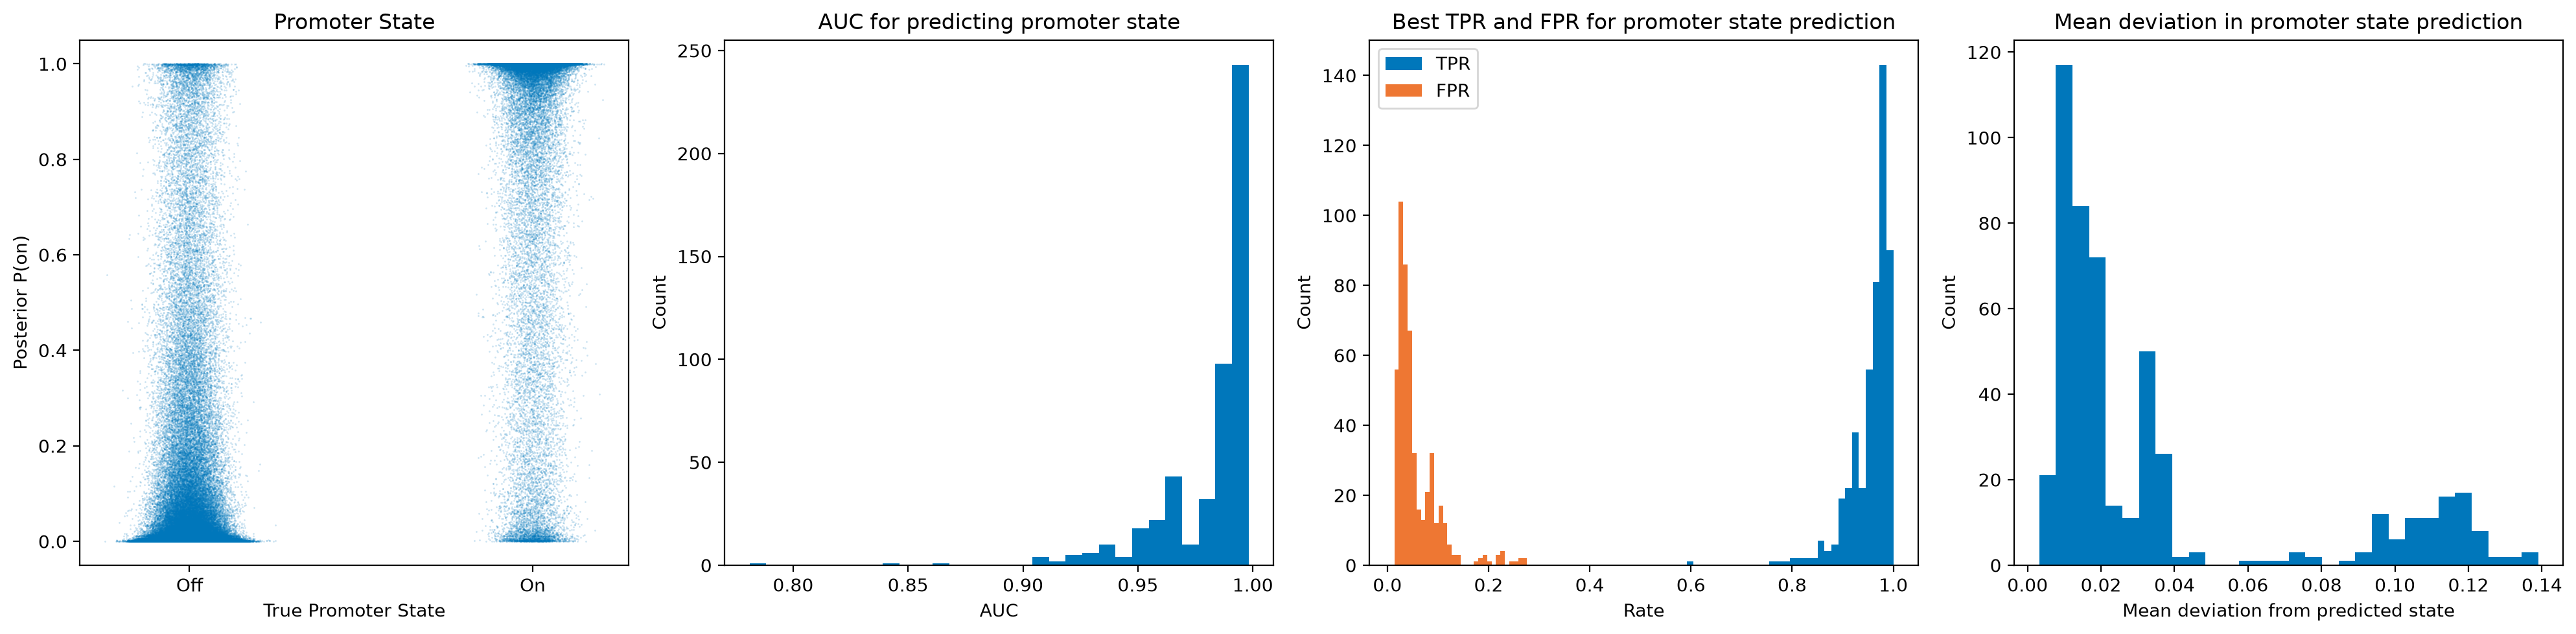

In [48]:
state_x = true_state.astype(float) + scatter_rng.normal(0, 0.05, size=true_state.size)
fig,all_ax = plt.subplots(1,4,figsize=(20,5))
all_axes = all_ax.flatten()
all_axes[0].scatter(
    state_x,
    pred_state,
    s=1,
    alpha=0.2,
    color=colors_pt["blue"],
    linewidths=0,
    rasterized=True,
)
all_axes[0].set(xlabel="True Promoter State", ylabel="Posterior P(on)", title="Promoter State",xticks = [0,1],xticklabels=["Off", "On"])
ax = all_ax[1:]
_ = ax[0].hist(df["AUC"],bins=30,color=colors_pt["blue"])
ax[0].set(xlabel="AUC",ylabel="Count",title="AUC for predicting promoter state")
ax[1].hist(df["Best_TPR"],bins=30,label='TPR',color=colors_pt["blue"])
_ = ax[1].hist(df["Best_FPR"],bins=30,label='FPR',color=colors_pt["orange"])
ax[1].set(xlabel="Rate",ylabel="Count",title="Best TPR and FPR for promoter state prediction")
ax[1].legend()
_ = ax[2].hist(df["state_deviation_mean"],bins=30,color=colors_pt["blue"])
ax[2].set(xlabel="Mean deviation from predicted state",ylabel="Count",title="Mean deviation in promoter state prediction")   
fig.tight_layout()
fig.savefig("figures/Supplement_figures/MS2_validation/Promoter_state_reconstruction.pdf")

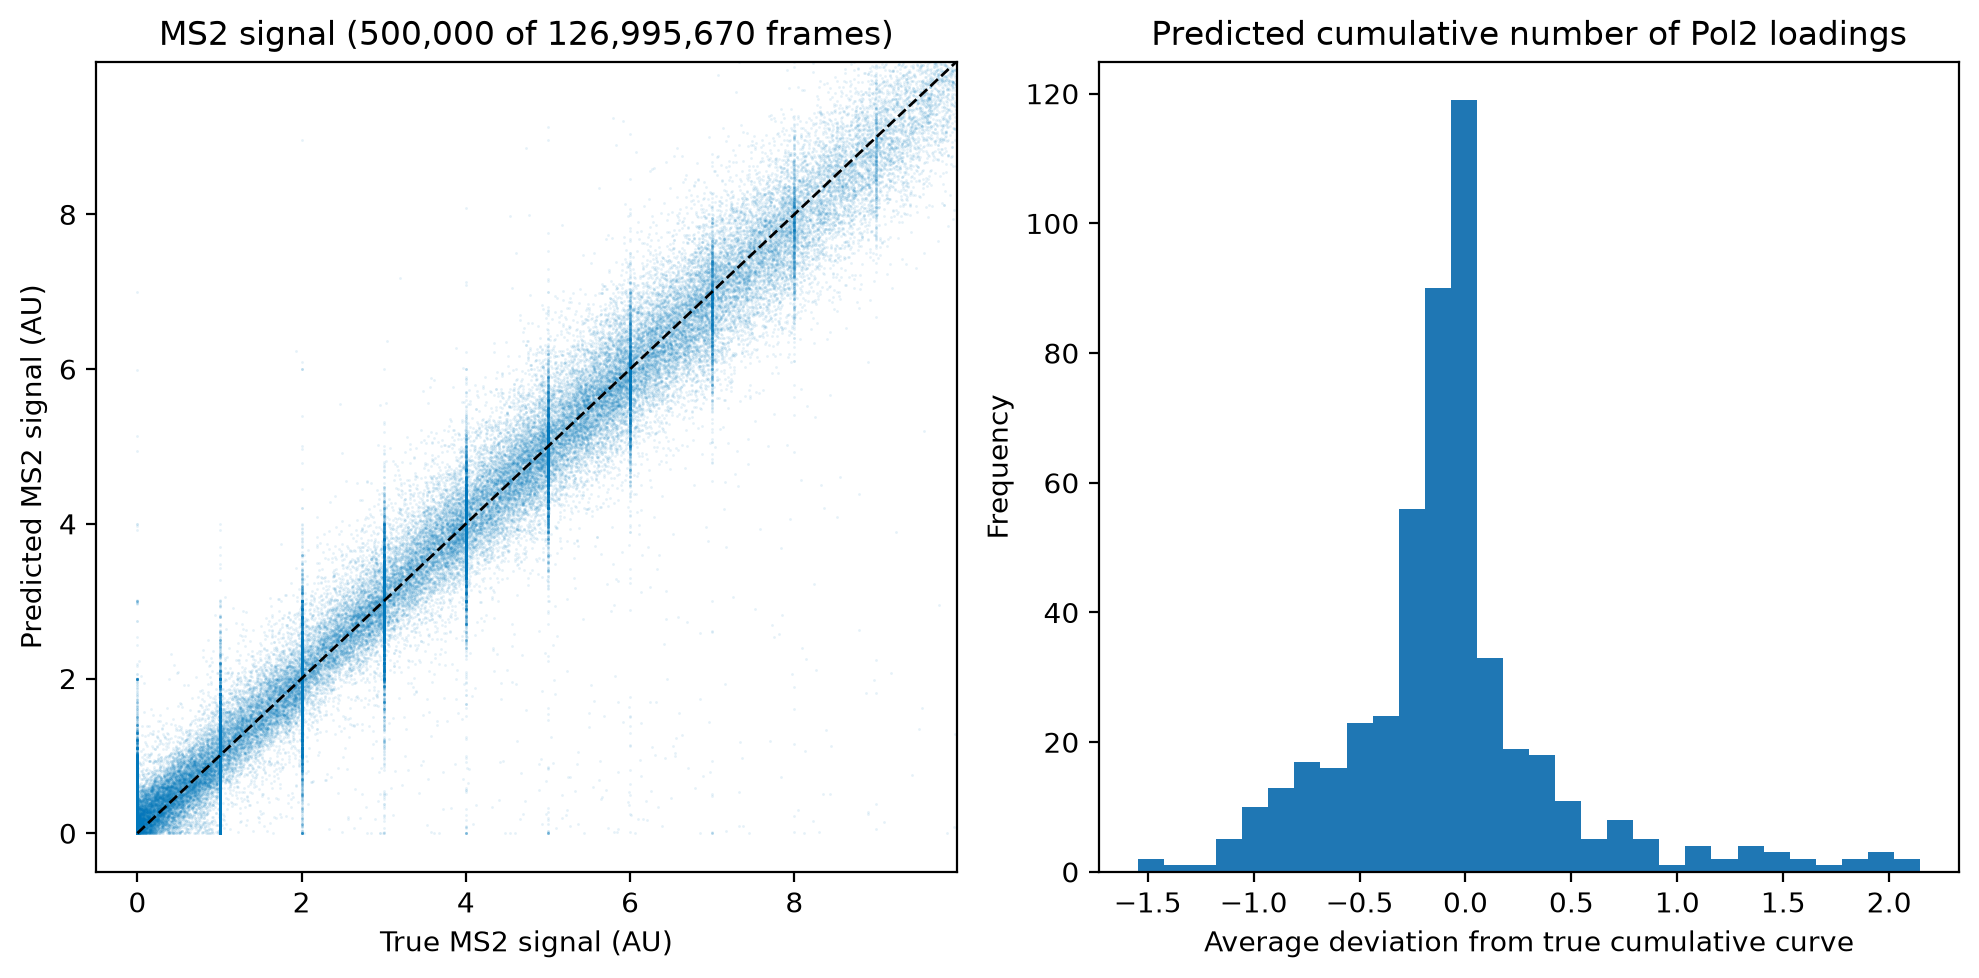

In [49]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ms2_max = np.nanpercentile(np.concatenate([true_ms2, pred_ms2]), 99.5)
ax[0].scatter(
    true_ms2,
    pred_ms2,
    s=1,
    alpha=0.1,
    color=colors_pt["blue"],
    linewidths=0,
    rasterized=True,
)
ax[0].plot([0, ms2_max], [0, ms2_max], color="black", linestyle="--", linewidth=1)
ax[0].set(
    xlabel="True MS2 signal (AU)",
    ylabel="Predicted MS2 signal (AU)",
    xlim=(-0.5, ms2_max),
    ylim=(-0.5, ms2_max),
    title=f"MS2 signal ({len(true_ms2):,} of {n_ms2_total:,} frames)",
)

ax[1].hist(df["mean_event_deviation"],bins=30)  
ax[1].set(xlabel="Average deviation from true cumulative curve",ylabel="Frequency",title="Predicted cumulative number of Pol2 loadings")
fig.tight_layout()
fig.savefig("figures/Supplement_figures/MS2_validation/MS2_signal_prediction.pdf")

kon=0.0670, koff=0.1250
SNR=0.88, dt=0.5


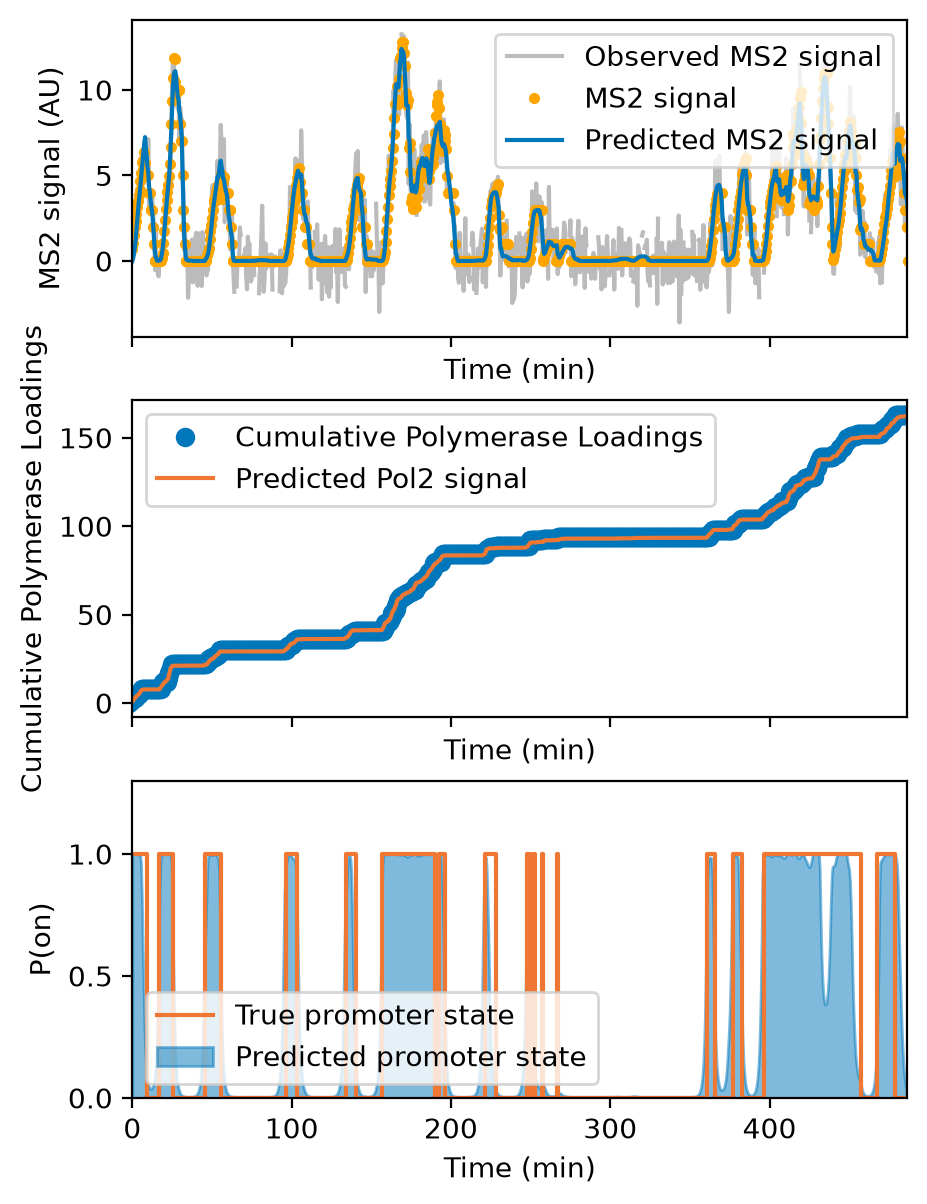

In [84]:

results = "Data/MS2_test_data/inference_results"
true_dat_path = "Data/MS2_test_data"
result_files = sorted(f for f in os.listdir(results) if f.endswith(".pkl"))
true_files = sorted(f for f in os.listdir(true_dat_path) if f.endswith(".pkl"))

fig,ax = plt.subplots(3,1,figsize=(5,7),sharex=True)

T_rise = 3
T_plateau = 5    
Tmax = 500
np.random.seed(42)
file_ind  = np.random.randint(0, len(result_files))    
filename = result_files[file_ind]
ind = filename.split("ind=")[1].split("_")[0]
true_data_file = [f for f in true_files if f"ind={ind}_" in f][0]

with open(os.path.join(true_dat_path, true_data_file), "rb") as f:
    true_data = pickle.load(f)
    
with open(os.path.join(results,filename), "rb") as f:
    result_data = pickle.load(f)    
state_pred = result_data["M"].get("Promoter State")["masked_posterior"][1:,:,0].T
MS2_pred = result_data["M"].get("Polymerase Loadings")["Predicted MS2"]
Pol2_pred = result_data["M"].get("Polymerase Loadings")["Pol2_posterior"]
    
observed_data = true_data["observed_dataset"]
dt = float(filename.split("_dt=")[1].split("_")[0])    
sampling_times = np.linspace(0, Tmax, int(Tmax / dt) + 1)
hidden_data = true_data["hidden_dataset"]
ind = np.random.randint(0, len(observed_data))

trace = observed_data[ind]
times, states, events, ms2_signal = true_data["hidden_dataset"][ind]
times = np.concatenate([times, [sampling_times[-1]]])
states = np.concatenate([states, [states[-1]]])
ax[0].plot(sampling_times,trace, label='Observed MS2 signal',color=colors_pt["grey"])
ax[0].plot(sampling_times, ms2_signal, ".",label='MS2 signal',color="orange")
ax[0].plot(sampling_times, MS2_pred[ind], label='Predicted MS2 signal',color=colors_pt["blue"])

ts = np.linspace(-T_rise-T_plateau, np.max(sampling_times[~np.isnan(trace)]), 1000)
cumulative = np.sum(events[:,None]-T_rise-T_plateau<ts[None,:], axis=0)
ax[1].plot(ts, cumulative,"o", label='Cumulative Polymerase Loadings', color=colors_pt["blue"])
ax[1].plot(sampling_times, np.cumsum(Pol2_pred[ind])*(sampling_times[1]-sampling_times[0]), label='Predicted Pol2 signal', color=colors_pt["orange"])


ax[2].step(times-T_rise-T_plateau, np.abs(states-1), where='post', label='True promoter state', color=colors_pt["orange"])
ax[2].fill_between(sampling_times, 0,state_pred[ind],color=colors_pt["blue"],alpha=0.5, label='Predicted promoter state')



kon = float(filename.split("_kon=")[1].split("_")[0])
koff = float(filename.split("_koff=")[1].split("_")[0])
snr = float(filename.split("_snr=")[1].split("_")[0])
dt = float(filename.split("_dt=")[1].split("_")[0])
print(f"kon={kon:.4f}, koff={koff:.4f}\nSNR={snr:.2f}, dt={dt:.1f}")
tmax = np.max(sampling_times[~np.isnan(trace)])
ax[2].set_xlim(0, tmax)
ax[0].set(xlabel="Time (min)", ylabel="MS2 signal (AU)")
ax[1].set(xlabel="Time (min)", ylabel="Cumulative Polymerase Loadings")
ax[2].set(xlabel="Time (min)", ylabel="P(on)",ylim=(0,1.3))

ax[0].legend()
ax[1].legend()
ax[2].legend(loc="lower left")
fig.savefig("figures/Supplement_figures/MS2_validation/Prediction_example.pdf")

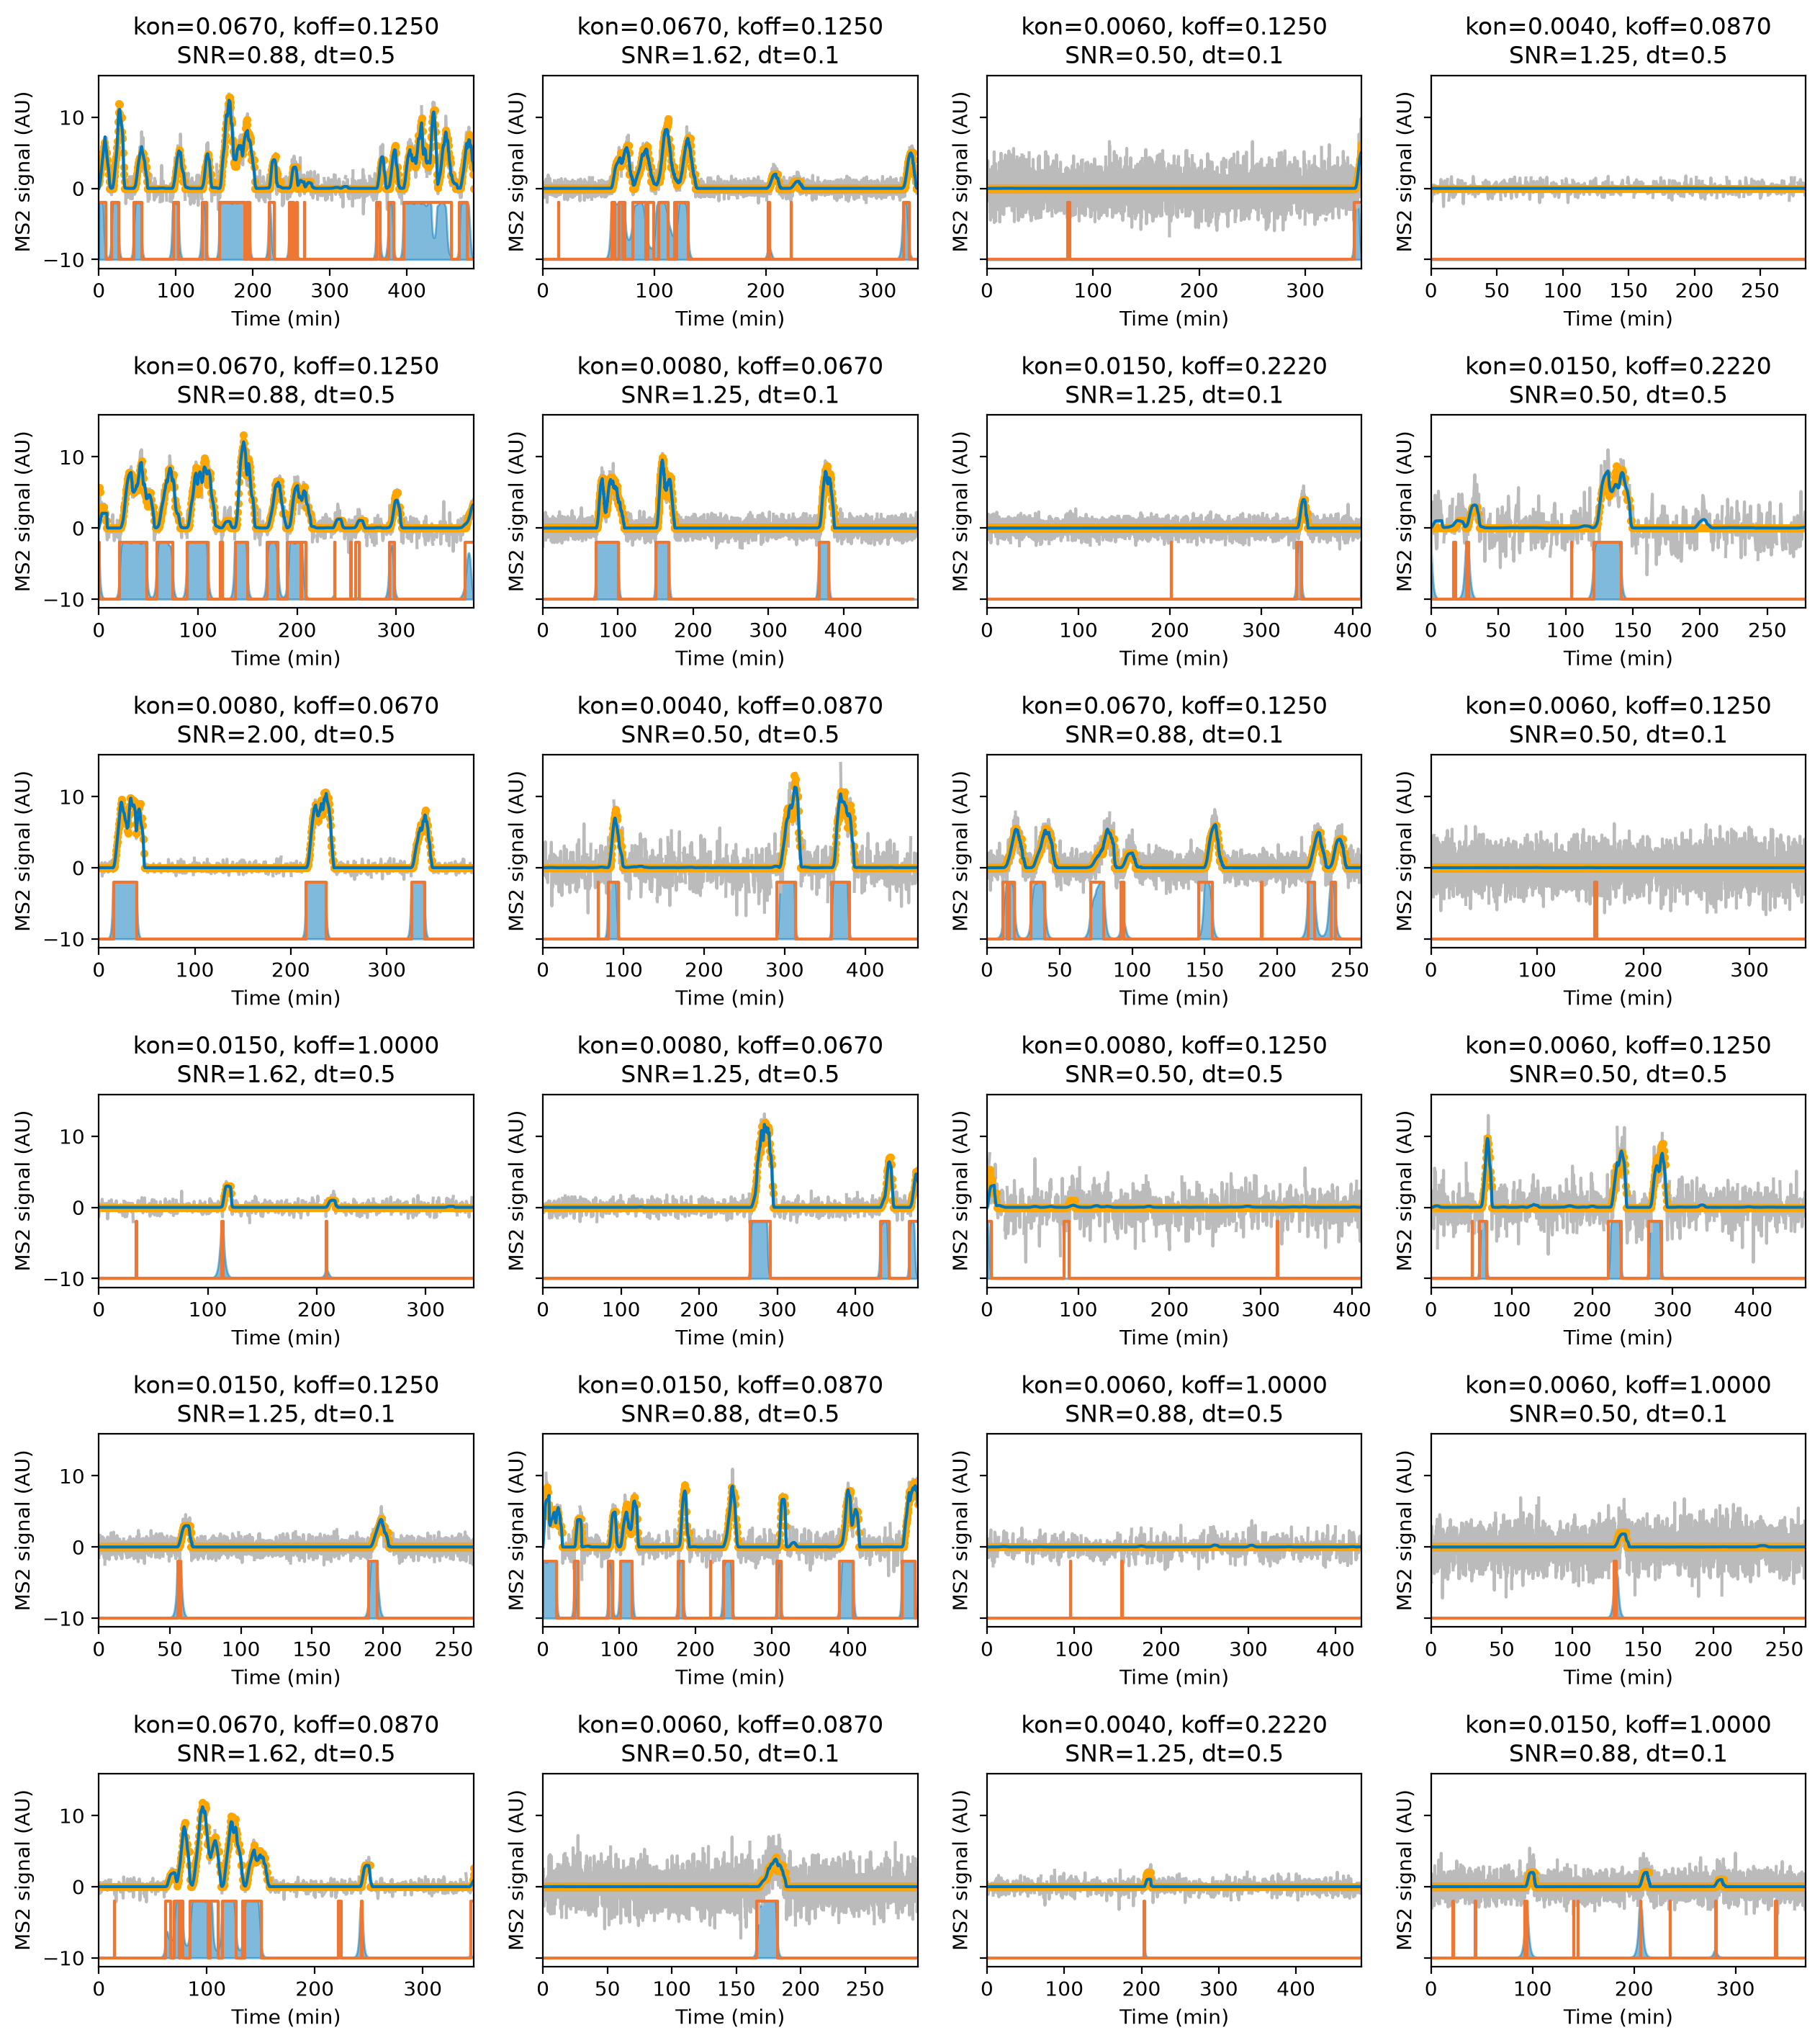

In [51]:

results = "Data/MS2_test_data/inference_results"
true_dat_path = "Data/MS2_test_data"
result_files = sorted(f for f in os.listdir(results) if f.endswith(".pkl"))
true_files = sorted(f for f in os.listdir(true_dat_path) if f.endswith(".pkl"))

fig,ax = plt.subplots(6,4,figsize=(8.5*1.5,11*1.3),sharey=True)
ntot = 24
T_rise = 3
T_plateau = 5    
Tmax = 500
np.random.seed(42)
for i in range(ntot):
    # draw random dataset
    rand_idx = np.random.randint(0, len(result_files))
    filename = result_files[rand_idx]
    
    ind = filename.split("ind=")[1].split("_")[0]
    true_data_file = [f for f in true_files if f"ind={ind}_" in f][0]

    with open(os.path.join(true_dat_path, true_data_file), "rb") as f:
        true_data = pickle.load(f)
        
    with open(os.path.join(results,filename), "rb") as f:
        result_data = pickle.load(f)    
    state_pred = result_data["M"].get("Promoter State")["masked_posterior"][1:,:,0].T
    MS2_pred = result_data["M"].get("Polymerase Loadings")["Predicted MS2"]
        
    observed_data = true_data["observed_dataset"]
    dt = float(filename.split("_dt=")[1].split("_")[0])    
    sampling_times = np.linspace(0, Tmax, int(Tmax / dt) + 1)
    hidden_data = true_data["hidden_dataset"]
    ind = np.random.randint(0, len(observed_data))
    
    trace = observed_data[ind]
    times, states, events, ms2_signal = true_data["hidden_dataset"][ind]
    times = np.concatenate([times, [sampling_times[-1]]])
    states = np.concatenate([states, [states[-1]]])
    ax.flatten()[i].plot(sampling_times,trace, label='Observed MS2 signal',color=colors_pt["grey"])
    ax.flatten()[i].plot(sampling_times, ms2_signal, ".",label='MS2 signal',color="orange")
    ax.flatten()[i].plot(sampling_times, MS2_pred[ind], label='Predicted MS2 signal',color=colors_pt["blue"])
    
    ax.flatten()[i].step(times-T_rise-T_plateau, np.abs(states-1)*8-10, where='post', label='True promoter state', color=colors_pt["orange"])
    ax.flatten()[i].fill_between(sampling_times, -10,-10+state_pred[ind]*8,color=colors_pt["blue"],alpha=0.5)
    
    
    kon = float(filename.split("_kon=")[1].split("_")[0])
    koff = float(filename.split("_koff=")[1].split("_")[0])
    snr = float(filename.split("_snr=")[1].split("_")[0])
    dt = float(filename.split("_dt=")[1].split("_")[0])
    ax.flatten()[i].set_title(f"kon={kon:.4f}, koff={koff:.4f}\nSNR={snr:.2f}, dt={dt:.1f}")
    tmax = np.max(sampling_times[~np.isnan(trace)])
    ax.flatten()[i].set_xlim(0, tmax)
    ax.flatten()[i].set(xlabel="Time (min)", ylabel="MS2 signal (AU)")
# set labels on outer axes
for a in ax[:,0]:
    a.set(ylabel="MS2 signal (AU)")
for a in ax[-1,:]:
    a.set(xlabel="Time (min)")
fig.tight_layout()
fig.savefig("figures/Supplement_figures/MS2_validation/Example_trajectories.pdf")